In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping 
from sklearn.preprocessing import LabelEncoder

## Load data

In [2]:
import pandas as pd
import json

# Load photos.csv
csv_file = r'C:\Users\anjit\Computer Vision\photos.csv'  # Use raw string literal
df = pd.read_csv(csv_file)



# Show the first few rows of the dataframe

import json

# Path to your JSON file
json_file = 'C:/Users/anjit/Computer Vision/photos_data.json'

photo_data_list = []

# Open the JSON file and read line by line
with open(json_file, 'r') as f:
    for line in f:
        try:
            photo_data = json.loads(line.strip())  # Remove any extra spaces/newlines
            photo_data_list.append(photo_data)  # Add to list
        except json.JSONDecodeError as e:
            print(f"Error decoding JSON: {e} - Skipping line")

# Check the first few records
print(photo_data_list[:3])  # Print the first 3 records to verify

print(df.head())

[{'photo_id': 'zsvj7vloL4L5jhYyPIuVwg', 'business_id': 'Nk-SJhPlDBkAZvfsADtccA', 'caption': 'Nice rock artwork everywhere and craploads of taps.', 'label': 'inside'}, {'photo_id': 'HCUdRJHHm_e0OCTlZetGLg', 'business_id': 'yVZtL5MmrpiivyCIrVkGgA', 'caption': '', 'label': 'outside'}, {'photo_id': 'vkr8T0scuJmGVvN2HJelEA', 'business_id': '_ab50qdWOk0DdB6XOrBitw', 'caption': 'oyster shooter', 'label': 'drink'}]
                 photo_id             business_id  \
0  zsvj7vloL4L5jhYyPIuVwg  Nk-SJhPlDBkAZvfsADtccA   
1  HCUdRJHHm_e0OCTlZetGLg  yVZtL5MmrpiivyCIrVkGgA   
2  vkr8T0scuJmGVvN2HJelEA  _ab50qdWOk0DdB6XOrBitw   
3  pve7D6NUrafHW3EAORubyw  SZU9c8V2GuREDN5KgyHFJw   
4  H52Er-uBg6rNrHcReWTD2w  Gzur0f0XMkrVxIwYJvOt2g   

                                             caption    label  
0  Nice rock artwork everywhere and craploads of ...   inside  
1                                                NaN  outside  
2                                     oyster shooter    drink  
3             

In [41]:
# Randomly sample 1000 rows
sampled_df = df.sample(n=1000, random_state=42)

# Check the sampled data
print(sampled_df.head())


                      photo_id             business_id              caption  \
32568   k_PSngRS22mSA1MypwrjPg  DzzVSYXadZ1_XgfGz_Loyw  Chocolate Croissant   
174911  D_94KivwVgitkzFIgE_KcQ  Xdzir62WKlSzeu4PMQtlBA                  NaN   
132444  Hf39P7_G_eRCqfVwvMDV6g  z0HzwNBmx_BgdiYI4hLk3g    Happy Anniversary   
46744   agxl4sABeRXwjLL506KMrQ  HzRSWmNxcEVQGrr1tun25w       Frozen Puccino   
85073   7cZ0MREN2TwAAX4nnirQlA  aj0urA2r2WlqZKufeB5dpw  Double Cheeseburger   

        label  
32568    food  
174911   food  
132444  drink  
46744    food  
85073    food  


## Resizing

In [42]:
import os
from PIL import Image

# Define the image folder and target size
image_folder = 'C:/Users/anjit/Computer Vision/images/'
target_size = (224, 224)

# Function to resize images in the sampled dataframe
def resize_image(photo_id):
    try:
        # Construct the image path
        image_path = os.path.join(image_folder, f'{photo_id}.jpg')
        
        # Open and resize the image
        with Image.open(image_path) as img:
            img_resized = img.resize(target_size)
            # Save the resized image (overwrite the original or save in a new folder)
            img_resized.save(image_path)
    except Exception as e:
        print(f"Error processing image {photo_id}: {e}")

# Resize images for the sampled subset
for photo_id in sampled_df['photo_id']:
    resize_image(photo_id)

print("Resizing complete for sampled images!")


Resizing complete for sampled images!


## Data augmentation

In [5]:
import cv2
import numpy as np
import random
from PIL import Image, ImageEnhance

# Augmentation Functions
def augment_image(photo_id):
    try:
        image_path = os.path.join(image_folder, f'{photo_id}.jpg')
        img = Image.open(image_path)

        # Apply random transformations
        if random.random() < 0.3:
            img = img.transpose(Image.FLIP_LEFT_RIGHT)  # Horizontal Flip
        if random.random() < 0.3:
            enhancer = ImageEnhance.Brightness(img)
            img = enhancer.enhance(random.uniform(0.7, 1.3))  # Random Brightness
        if random.random() < 0.3:
            img = img.rotate(random.choice([90, 180, 270]))  # Random Rotation
        if random.random() < 0.3:
            img = img.crop((10, 10, img.width - 10, img.height - 10))  # Random Cropping

        # Save Augmented Image
        img.save(image_path)
    
    except Exception as e:
        print(f"Error processing image {photo_id}: {e}")

# Apply Augmentations to Sampled Dataset
for photo_id in sampled_df['photo_id']:
    augment_image(photo_id)

print("Image augmentation completed!")


Image augmentation completed!


## Combine images

In [6]:
def combine_images(photo_id1, photo_id2, save_path):
    try:
        image1_path = os.path.join(image_folder, f'{photo_id1}.jpg')
        image2_path = os.path.join(image_folder, f'{photo_id2}.jpg')

        # Open images
        img1 = Image.open(image1_path)
        img2 = Image.open(image2_path)

        # Resize to match dimensions
        img2 = img2.resize(img1.size)

        # Combine side by side
        combined = Image.new('RGB', (img1.width * 2, img1.height))
        combined.paste(img1, (0, 0))
        combined.paste(img2, (img1.width, 0))

        # Save Combined Image
        combined.save(save_path)

    except Exception as e:
        print(f"Error combining images {photo_id1} and {photo_id2}: {e}")

# Example: Combine first two images in sampled data
combine_images(sampled_df['photo_id'].iloc[0], sampled_df['photo_id'].iloc[1], "combined_sample.jpg")

print("Image combination completed!")


Image combination completed!


## Intensity Thresholding

In [7]:
def apply_threshold(photo_id):
    try:
        image_path = os.path.join(image_folder, f'{photo_id}.jpg')
        img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

        # Apply thresholding
        _, thresh = cv2.threshold(img, 128, 255, cv2.THRESH_BINARY)

        # Save thresholded image
        cv2.imwrite(image_path, thresh)
    
    except Exception as e:
        print(f"Error processing image {photo_id}: {e}")

# Apply to all sampled images
for photo_id in sampled_df['photo_id']:
    apply_threshold(photo_id)

print("Thresholding applied to images!")


Thresholding applied to images!


## Histogram Equalization

In [8]:
def apply_histogram_equalization(photo_id):
    try:
        image_path = os.path.join(image_folder, f'{photo_id}.jpg')
        img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

        # Apply Histogram Equalization
        equalized = cv2.equalizeHist(img)

        # Save the new image
        cv2.imwrite(image_path, equalized)
    
    except Exception as e:
        print(f"Error processing image {photo_id}: {e}")

# Apply to all sampled images
for photo_id in sampled_df['photo_id']:
    apply_histogram_equalization(photo_id)

print("Histogram equalization applied!")


Histogram equalization applied!


## Gaussian Blur

In [9]:
def apply_gaussian_blur(photo_id):
    try:
        image_path = os.path.join(image_folder, f'{photo_id}.jpg')
        img = cv2.imread(image_path)

        # Apply Gaussian Blur
        blurred = cv2.GaussianBlur(img, (5, 5), 0)

        # Save the blurred image
        cv2.imwrite(image_path, blurred)
    
    except Exception as e:
        print(f"Error processing image {photo_id}: {e}")

# Apply to all sampled images
for photo_id in sampled_df['photo_id']:
    apply_gaussian_blur(photo_id)

print("Gaussian blur applied!")


Gaussian blur applied!


## Data split

In [10]:
# Split the dataframe into training and testing sets
train_df, test_df = train_test_split(sampled_df, test_size=0.2, random_state=42)

# Load images and labels for training set
X_train = []
y_train = []

for index, row in train_df.iterrows():
    photo_id = row['photo_id']
    label = row['label']  # Replace 'label' with the actual column name for labels
    image_path = os.path.join(image_folder, f'{photo_id}.jpg')
    img = Image.open(image_path)
    img = img.resize((224, 224))  # Ensure all images are resized
    img_array = np.array(img) / 255.0  # Normalize pixel values to [0, 1]
    X_train.append(img_array)
    y_train.append(label)

# Load images and labels for testing set
X_test = []
y_test = []

for index, row in test_df.iterrows():
    photo_id = row['photo_id']
    label = row['label']  # Replace 'label' with the actual column name for labels
    image_path = os.path.join(image_folder, f'{photo_id}.jpg')
    img = Image.open(image_path)
    img = img.resize((224, 224))  # Ensure all images are resized
    img_array = np.array(img) / 255.0  # Normalize pixel values to [0, 1]
    X_test.append(img_array)
    y_test.append(label)

# Convert to numpy arrays
X_train = np.array(X_train)
y_train = np.array(y_train)
X_test = np.array(X_test)
y_test = np.array(y_test)



# Initialize LabelEncoder
le = LabelEncoder()

# Fit and transform y_train
y_train = le.fit_transform(y_train)

# Transform y_test (using the same encoder)
y_test = le.transform(y_test)


y_train = y_train.astype('float32')
y_test = y_test.astype('float32')
X_train = X_train.astype('float32')
X_test = X_test.astype('float32')

In [11]:
print(f"X_train shape: {X_train.shape}, X_train dtype: {X_train.dtype}")
print(f"X_test shape: {X_test.shape}, X_test dtype: {X_test.dtype}")
print(f"y_train shape: {y_train.shape}, y_train dtype: {y_train.dtype}")
print(f"y_test shape: {y_test.shape}, y_test dtype: {y_test.dtype}")

X_train shape: (800, 224, 224, 3), X_train dtype: float32
X_test shape: (200, 224, 224, 3), X_test dtype: float32
y_train shape: (800,), y_train dtype: float32
y_test shape: (200,), y_test dtype: float32


## Build the CNN Model

In [12]:
from tensorflow.keras import models, layers

def build_cnn_model(input_shape=(224, 224, 3)):
    model = models.Sequential([
        # Convolutional layers
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(128, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),

        # Fully connected layers
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),  # Dropout to prevent overfitting
        layers.Dense(5, activation='softmax')  # 5 classes
    ])

    # Compile the model
    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',  # Use this loss for integer labels
                  metrics=['accuracy'])

    return model

# Build the model
cnn_model = build_cnn_model()
cnn_model.summary()


C:\Users\anjit\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 222, 222, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 111, 111, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 109, 109, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 54, 54, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 52, 52, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 26, 26, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 86528)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │      11,075,712 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 5)                   │             645 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 11,169,605 (42.61 MB)

 Trainable params: 11,169,605 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = cnn_model.fit(
    X_train, y_train,
    epochs=20,
    validation_data=(X_test, y_test),
    batch_size=32,
    callbacks=[early_stopping]
)


Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 154s 5s/step - accuracy: 0.4960 - loss: 1.8645 - val_accuracy: 0.5250 - val_loss: 1.1655
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 132s 5s/step - accuracy: 0.5659 - loss: 1.0988 - val_accuracy: 0.5900 - val_loss: 1.0695
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 123s 5s/step - accuracy: 0.6458 - loss: 0.9288 - val_accuracy: 0.6000 - val_loss: 1.0812
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 117s 5s/step - accuracy: 0.7028 - loss: 0.7920 - val_accuracy: 0.5750 - val_loss: 1.2802
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 99s 4s/step - accuracy: 0.7812 - loss: 0.5812 - val_accuracy: 0.5900 - val_loss: 1.4556
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 119s 3s/step - accuracy: 0.8481 - loss: 0.3791 - val_accuracy: 0.5700 - val_loss: 1.6870
Epoch 7/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 63s 3s/step - accuracy: 0.9405 - loss: 0.1979 - val_accuracy: 0.5900 - val_loss: 2.2475


## Model Evaluation

In [14]:
test_loss, test_acc = cnn_model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_acc:.4f}")


7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 507ms/step - accuracy: 0.5586 - loss: 1.1386
Test Accuracy: 0.5900


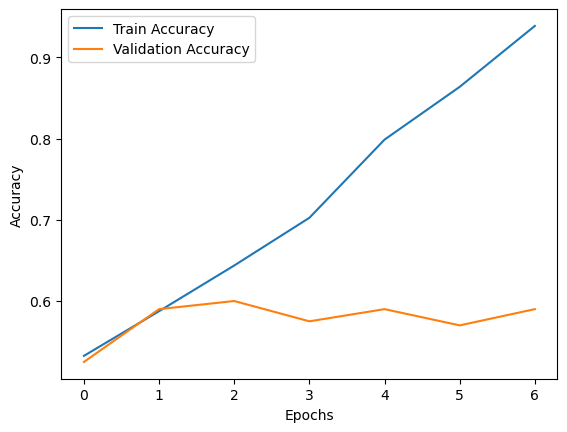

In [15]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


In [16]:
from sklearn.metrics import roc_auc_score
import numpy as np

# Get predicted probabilities (using softmax for multi-class classification)
y_pred_proba = cnn_model.predict(X_test)

# Compute AUC
# For multi-class, roc_auc_score can handle one-vs-rest, using the multi_class='ovr' argument
auc = roc_auc_score(y_test, y_pred_proba, multi_class='ovr')

print(f'AUC: {auc:.4f}')


7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 582ms/step
AUC: 0.6227


In [17]:
#confusion matrix

7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 548ms/step
Confusion Matrix:
[[  0   7   2   0   0]
 [  0 101   5   0   0]
 [  0  43  17   0   0]
 [  0   3   0   0   0]
 [  0  18   4   0   0]]


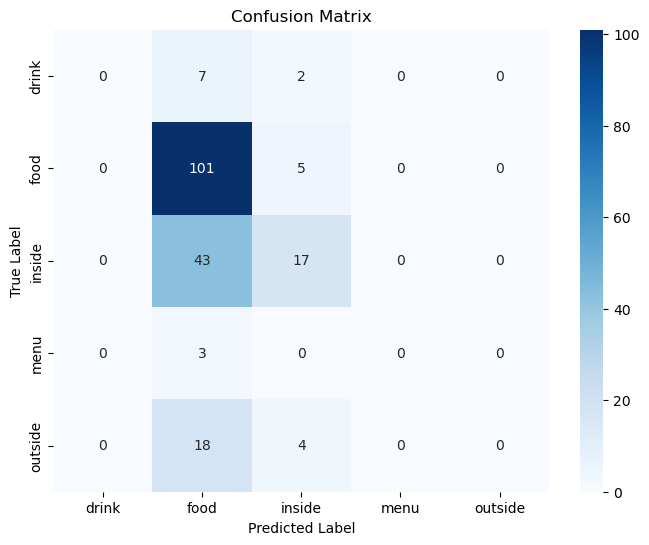

In [18]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Predict the labels for the test set
y_pred = cnn_model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)  # Convert probabilities to class labels

# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred_classes)
# Print confusion matrix values
print("Confusion Matrix:")
print(cm)
# Plot confusion matrix using seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()


## Model Tuning

In [20]:
from tensorflow.keras.callbacks import ReduceLROnPlateau

# Example of adjusting the learning rate when validation loss plateaus
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)

history = cnn_model.fit(
    X_train, y_train,
    epochs=20,
    validation_data=(X_test, y_test),
    batch_size=32,
    callbacks=[early_stopping, lr_scheduler]
)


Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 69s 3s/step - accuracy: 0.6623 - loss: 0.9776 - val_accuracy: 0.6000 - val_loss: 1.0890 - learning_rate: 0.0010
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 83s 3s/step - accuracy: 0.6636 - loss: 0.8792 - val_accuracy: 0.5900 - val_loss: 1.1049 - learning_rate: 0.0010
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 162s 4s/step - accuracy: 0.7418 - loss: 0.6896 - val_accuracy: 0.5850 - val_loss: 1.4077 - learning_rate: 0.0010
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 89s 4s/step - accuracy: 0.8230 - loss: 0.4421 - val_accuracy: 0.5700 - val_loss: 1.6332 - learning_rate: 0.0010
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 159s 4s/step - accuracy: 0.9163 - loss: 0.2419 - val_accuracy: 0.5550 - val_loss: 2.1678 - learning_rate: 5.0000e-04
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 131s 5s/step - accuracy: 0.9650 - loss: 0.1190 - val_accuracy: 0.5600 - val_loss: 2.4877 - learning_rate: 5.0000e-04


## Save model

In [22]:
# Save the entire model
cnn_model.save('my_model.keras')  # Saves the model to a .keras file

# Save the weights (with the correct file extension)
cnn_model.save_weights('my_model_weights.weights.h5')


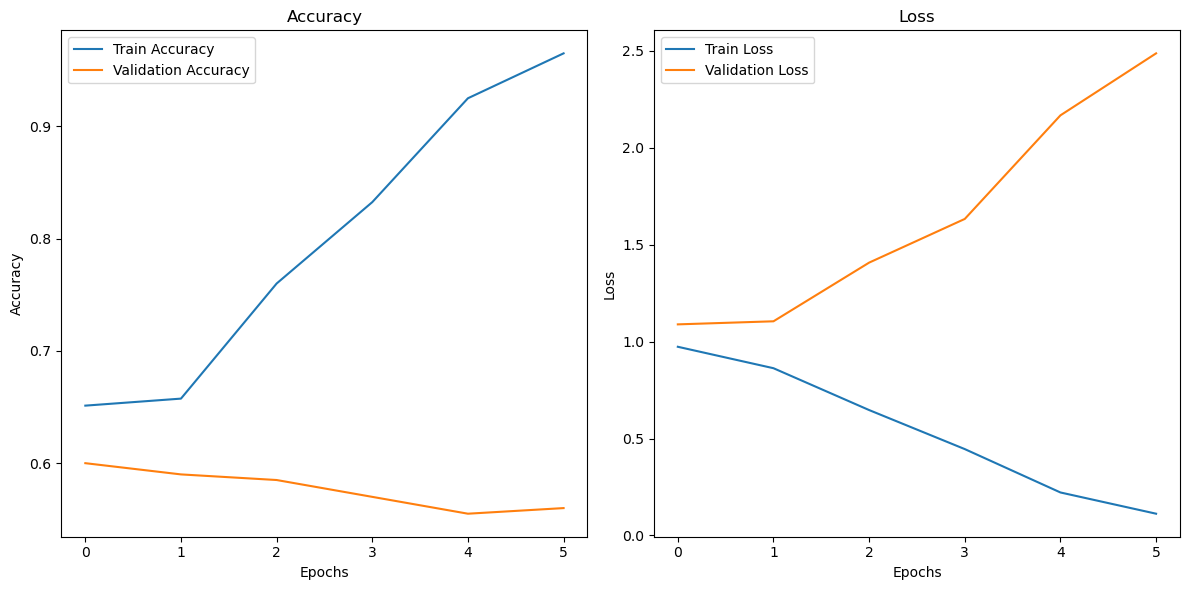

In [23]:
# Plot training & validation accuracy
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot training & validation loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()



In [24]:
from sklearn.metrics import roc_auc_score
import numpy as np

# Get predicted probabilities (using softmax for multi-class classification)
y_pred_proba = cnn_model.predict(X_test)

# Compute AUC
# For multi-class, roc_auc_score can handle one-vs-rest, using the multi_class='ovr' argument
auc = roc_auc_score(y_test, y_pred_proba, multi_class='ovr')

print(f'AUC: {auc:.4f}')


7/7 ━━━━━━━━━━━━━━━━━━━━ 7s 689ms/step
AUC: 0.6177


7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 595ms/step
Confusion Matrix:
[[ 0  7  2  0  0]
 [ 0 99  7  0  0]
 [ 0 39 21  0  0]
 [ 0  3  0  0  0]
 [ 0 18  4  0  0]]


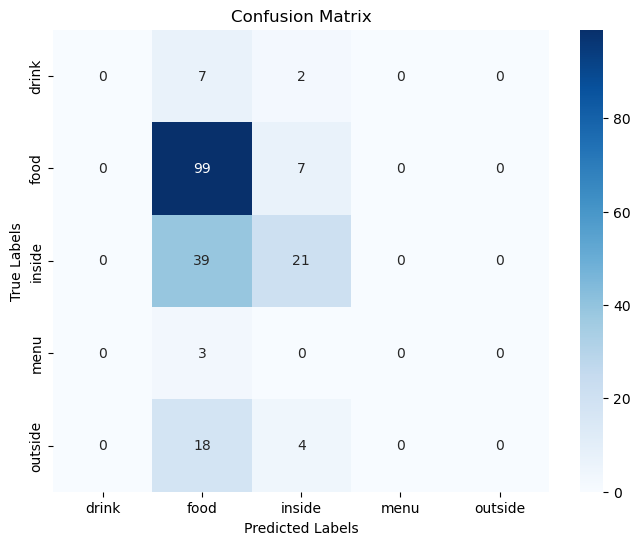

In [25]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Get predicted probabilities (using softmax for multi-class classification)
y_pred_proba = cnn_model.predict(X_test)

# Get the predicted class labels (argmax on probabilities)
y_pred = np.argmax(y_pred_proba, axis=1)

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Print confusion matrix values
print("Confusion Matrix:")
print(cm)

# Plot confusion matrix using seaborn heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()
